## 3.2.线性回归的从零开始实现
我们将从零开始实现整个方法， 包括数据流水线、模型、损失函数和小批量随机梯度下降优化器。 虽然现代的深度学习框架几乎可以自动化地进行所有这些工作，但从零开始实现可以确保我们真正知道自己在做什么。 同时，了解更细致的工作原理将方便我们自定义模型、自定义层或自定义损失函数。 在这一节中，我们将只使用张量和自动求导。 在之后的章节中，我们会充分利用深度学习框架的优势，介绍更简洁的实现方式。

In [1]:
import random
import torch
from d2l import torch as d2l

### 3.2.1.生成数据集
为了简单起见，我们将根据带有噪声的线性模型构造一个人造数据集。 我们的任务是使用这个有限样本的数据集来恢复这个模型的参数。 我们将使用低维数据，这样可以很容易地将其可视化。 在下面的代码中，我们生成一个包含1000个样本的数据集， 每个样本包含从标准正态分布中采样的2个特征。

In [3]:
def synthetic_data(w,b,num_examples):
    """生成y=Xw+b+噪声"""
    X = torch.normal(0,1,(num_examples,len(w))) # 创建一个形状为 (num_examples, len(w)) 的张量 X，其中的元素是从均值为 0、标准差为 1 的正态分布中随机抽取的。
    y = torch.matmul(X,w) + b # 矩阵乘法
    y += torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1)) # -1 表示该维度的大小由其他维度的大小来自动确定，而 1 表示将该维度的大小设置为 1。

true_w = torch.tensor([2,-3.4])
true_b = 4.2    
features,labels=synthetic_data(true_w,true_b,1000)

In [4]:
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([1.8577, 0.7258]) 
label: tensor([5.4501])


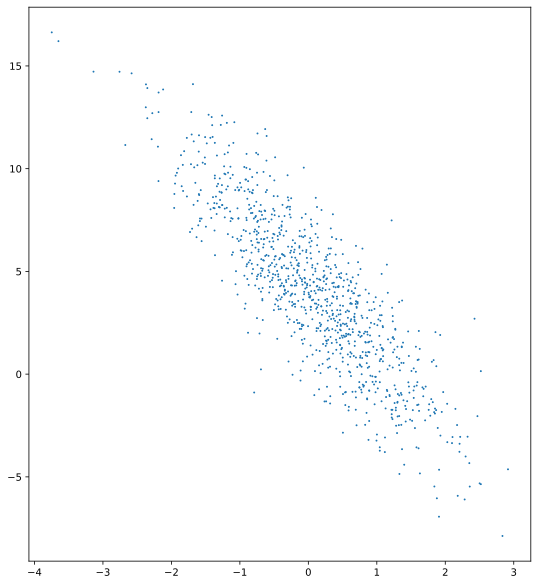

In [11]:
d2l.set_figsize((9,10))
d2l.plt.scatter(features[:,(1)].detach().numpy(),labels.detach().numpy(),1)

### 3.2.2.读取数据集
在下面的代码中，我们定义一个data_iter函数， 该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量。 每个小批量包含一组特征和标签。

In [13]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本都是随机读取，没有特定的顺序
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

In [20]:
batch_size = 10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.1164, -0.2120],
        [-2.0920, -0.9290],
        [-0.4937,  0.2821],
        [ 0.1366, -1.2971],
        [ 2.7912, -0.6301],
        [-0.5465,  0.2650],
        [ 2.3975,  0.3585],
        [-1.6951, -0.0178],
        [-1.9301,  0.8300],
        [ 0.4659, -1.1760]]) 
 tensor([[ 5.1430],
        [ 3.1883],
        [ 2.2441],
        [ 8.8791],
        [11.9271],
        [ 2.1842],
        [ 7.7808],
        [ 0.8545],
        [-2.4653],
        [ 9.1399]])


当我们运行迭代时，我们会连续地获得不同的小批量，直至遍历完整个数据集。 上面实现的迭代对教学来说很好，但它的执行效率很低，可能会在实际问题上陷入麻烦。 例如，它要求我们将所有数据加载到内存中，并执行大量的随机内存访问。 在深度学习框架中实现的内置迭代器效率要高得多， 它可以处理存储在文件中的数据和数据流提供的数据。

### 3.2.3.初始化模型
在我们开始用小批量随机梯度下降优化我们的模型参数之前， 我们需要先有一些参数。 在下面的代码中，我们通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重， 并将偏置初始化为0。

In [30]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)

### 3.2.4.定义模型
计算线性模型的输出， 我们只需计算输入特征X和模型权重w的矩阵-向量乘法后加上偏置b


In [18]:
def linreg(X,w,b):
    """线性回归模型"""
    return torch.matmul(X,w) + b

### 3.2.5.定义损失函数
因为需要计算损失函数的梯度，所以我们应该先定义损失函数。这里我们使用 3.1节中描述的平方损失函数。 在实现中，我们需要将真实值y的形状转换为和预测值y_hat的形状相同。

In [19]:
def squared_loss(y_hat,y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape))**2 /2

### 3.2.6.定义优化算法
在每一步中，使用从数据集中随机抽取的一个小批量，然后根据参数计算损失的梯度。 接下来，朝着减少损失的方向更新我们的参数。 下面的函数实现小批量随机梯度下降更新。 该函数接受模型参数集合、学习速率和批量大小作为输入。每 一步更新的大小由学习速率lr决定。 因为我们计算的损失是一个批量样本的总和，所以我们用批量大小（batch_size） 来规范化步长，这样步长大小就不会取决于我们对批量大小的选择。

In [23]:
def sgd(params,lr,batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr*param.grad / batch_size
            param.grad.zero_()

### 3.2.7.训练
在每次迭代中，我们读取一小批量训练样本，并通过我们的模型来获得一组预测。 计算完损失后，我们开始反向传播，存储每个参数的梯度。 最后，我们调用优化算法sgd来更新模型参数。
在每个迭代周期（epoch）中，我们使用data_iter函数遍历整个数据集， 并将训练数据集中所有样本都使用一次（假设样本数能够被批量大小整除）。 这里的迭代周期个数num_epochs和学习率lr都是超参数，分别设为3和0.03。 设置超参数很棘手，需要通过反复试验进行调整。 我们现在忽略这些细节

In [31]:
lr = 0.1
num_epochs = 10
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y) # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，并以此计算关于[w,b]的梯度
        l.sum().backward() # 求和标量化，backward()只支持对标量求导
        sgd([w,b],lr,batch_size) # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch{epoch + 1},loss{float(train_l.mean()):f}')

epoch1,loss0.000050
epoch2,loss0.000050
epoch3,loss0.000051
epoch4,loss0.000050
epoch5,loss0.000051
epoch6,loss0.000051
epoch7,loss0.000050
epoch8,loss0.000051
epoch9,loss0.000051
epoch10,loss0.000051


: 

因为我们使用的是自己合成的数据集，所以我们知道真正的参数是什么。 因此，我们可以通过比较真实参数和通过训练学到的参数来评估训练的成功程度。 事实上，真实参数和通过训练学到的参数确实非常接近。

In [26]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([4.5753e-04, 5.5075e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0002], grad_fn=<RsubBackward1>)
